In [1]:
import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb
import warnings

# Ignore matplotlib warnings
warnings.filterwarnings('ignore')

In [2]:
# Process raw time values from experiments
def process_time(df, time_var, time_limit):
    df.loc[df['status'] == 'TIMEOUT', time_var] = time_limit  # Consider TIMEOUTS as time limit
    filtered_df = df[df['status'].isin(['OK', 'TIMEOUT'])]  # Filter out ERRORS
    return filtered_df[time_var].apply(lambda t: min(t, time_limit))  # Time is at most time limit

In [3]:
# Create box plots
def generate_box_plots(parameter, group_filenames, labels, values, settings):
    # Prepare multiple box plots
    fig, axes = plt.subplots(1, len(group_filenames), sharey=values['share_y'], figsize=settings['figsize']) # Default Size: (6.4, 4.8)
    plt.subplots_adjust(wspace=settings['plot_separation'])

    # Support single plots
    if len(group_filenames) == 1:
        axes = [axes]

    # Title & Labels
    #fig.suptitle(labels['sup_title'], fontsize=12, fontweight='bold')
    #fig.supxlabel(labels['axes'][0])
    axes[0].set_ylabel(labels['axes'][1])

    # Legend
    for leg_idx, legend in enumerate(labels['legend']):
        legend_handles = [mpatches.Patch(facecolor=sb.color_palette()[color_idx], edgecolor='0.15') for color_idx in settings['legend_colors'][leg_idx]]
        for patch in legend_handles:  # Transparency
            fc = patch.get_facecolor()
            patch.set_facecolor(mpl.colors.to_rgba(fc, 0.8))
        fig.legend(handles=legend_handles,
                   labels=legend,
                   ncol=settings['legend_cols'][leg_idx],
                   loc='upper center',
                   bbox_to_anchor=settings['legend_anchor'][leg_idx],
                   frameon=False,
                   columnspacing=0.8,
                   handlelength=1.0,
                   handletextpad=0.3)

    # Create each box plot
    for idx, group in enumerate(group_filenames):
        # Load data from CSV files
        data_frames = [pd.read_csv(filename) for filename in group]
        data = [process_time(df, parameter, 60000) for df in data_frames]  # Process time values

        # Generate box plot from data
        custom_width = len(group) * settings['box_width_factor']
        colors = [sb.color_palette()[color_idx] for color_idx in values['colors'][idx]]
        plot = sb.boxplot(data, ax=axes[idx], showfliers=values['outliers'], width=custom_width, palette=colors)
        for patch in plot.patches:  # Transparency
            fc = patch.get_facecolor()
            patch.set_facecolor(mpl.colors.to_rgba(fc, 0.8))

        # Visualization settings

        # Title
        axes[idx].set_title(labels['sub_titles'][idx], fontsize=10)

        # X Axis
        x_labels = [tick + 1 for tick in values['x_axis'][idx]]
        axes[idx].set_xticklabels(x_labels)
        if values['separators'][idx] is not None:
            [axes[idx].axvline(sep, color='grey', linestyle='--') for sep in values['separators'][idx]]

        # Y Axis
        axes[idx].set_yscale(values['scale'])
        axes[idx].minorticks_off()
        axes[idx].grid(axis='y', linestyle='--')

    # Save image
    if settings['export']:
        plt.savefig(settings['output_filename'], bbox_inches='tight')

    # Display
    plt.show()

In [4]:
# Global settings
global_scale = 'log'  # Y axis scale, can be 'log' or 'linear'
global_outliers = False  # True for displaying outliers, False by default

# Engine names

# PG1: Neo4j
# PG2: Kuzu
# PG3: NebulaGraph
# S1: Jena
# S2: Virtuoso
# S3: Blazegraph

**Vanilla**

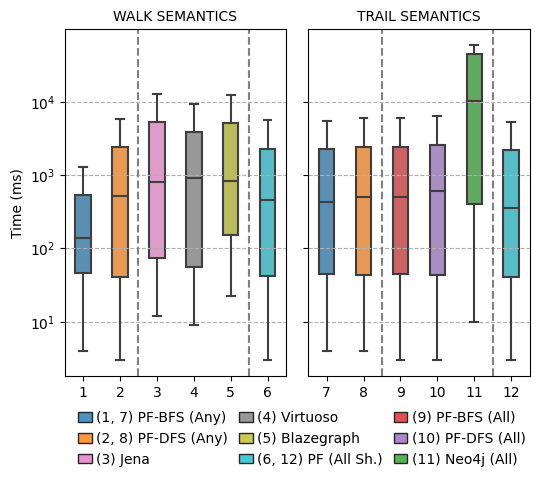

In [5]:
var = 'enum_time_ms'

# Legend
names_a = ['(1, 7) PF-BFS (Any)',
           '(2, 8) PF-DFS (Any)',
           '(3) Jena',
           '(4) Virtuoso',
           '(5) Blazegraph',
           '(6, 12) PF (All Sh.)',
           '(9) PF-BFS (All)',
           '(10) PF-DFS (All)',
           '(11) Neo4j (All)']
legend_colors_a = [0, 1, 6, 7, 8, 9, 3, 4, 2]

# Data for first plot
files_a = ['WDBench_old/wdbench_any_shortest_walks_bfs.csv',
           'WDBench/wdbench_any_walks_dfs.csv',
           'Old/WDBench/Endpoints/jena.csv',
           'Old/WDBench/Endpoints/virtuoso.csv',
           'Old/WDBench/Endpoints/blazegraph.csv',
           'WDBench/wdbench_all_shortest_walks_bfs.csv']
types_a = [0, 1, 2, 3, 4, 5]
colors_a = [0, 1, 6, 7, 8, 9]
separators_a = [1.5, 4.5]

# Data for second plot
files_b = ['WDBench/wdbench_any_trails_bfs.csv',
           'WDBench/wdbench_any_trails_dfs.csv',
           'WDBench/wdbench_all_trails_bfs.csv',
           'WDBench/wdbench_all_trails_dfs.csv',
           'Old/WDBench/All Trails/neo4j.csv',
           'WDBench/wdbench_shortest_1_groups_trails_bfs.csv']
types_b = [6, 7, 8, 9, 10, 11]
colors_b = [0, 1, 3, 4, 2, 9]
separators_b = [1.5, 4.5]

# Create box plots
sections = [files_a, files_b]
plot_labels = {'sup_title': 'WALKS + TRAILS',
               'sub_titles': ('WALK SEMANTICS', 'TRAIL SEMANTICS'),
               'axes': ('Engine', 'Time (ms)'),
               'legend': [names_a]}
value_settings = {'scale': global_scale,
                  'outliers': global_outliers,
                  'share_y': True,
                  'x_axis': [types_a, types_b],
                  'colors': [colors_a, colors_b],
                  'separators': [separators_a, separators_b]}
general_settings = {'legend_cols': [3],
                    'legend_colors': [legend_colors_a],
                    'figsize': (6, 4.5),
                    'plot_separation': 0.1,
                    'box_width_factor': 0.07,
                    'legend_anchor': [(0.52, 0.06)],
                    'export': True,
                    'output_filename': 'wdbench_vanilla.pdf'}
generate_box_plots(var, sections, plot_labels, value_settings, general_settings)

**Shortest K**

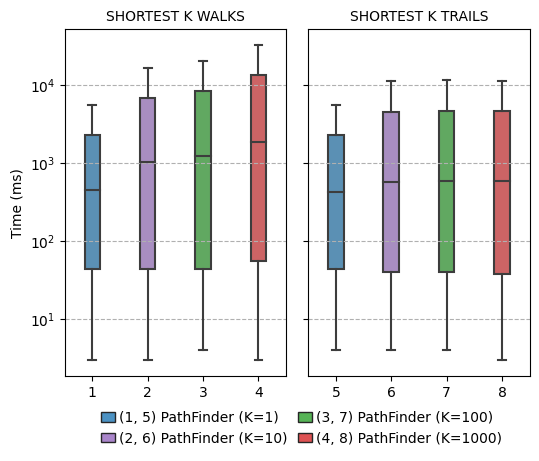

In [6]:
var = 'enum_time_ms'

# Legend
names_a = ['(1, 5) PathFinder (K=1)',
           '(2, 6) PathFinder (K=10)',
           '(3, 7) PathFinder (K=100)',
           '(4, 8) PathFinder (K=1000)']
legend_colors_a = [0, 4, 2, 3]

# Data for first plot
files_a = ['WDBench/wdbench_any_shortest_walks_bfs.csv',
           'WDBench/wdbench_shortest_10_walks_bfs.csv',
           'WDBench/wdbench_shortest_100_walks_bfs.csv',
           'WDBench/wdbench_shortest_1000_walks_bfs.csv',]
types_a = [0, 1, 2, 3]
colors_a = legend_colors_a
#separators_a = [1.5, 4.5]

# Data for second plot
files_b = ['WDBench/wdbench_any_trails_bfs.csv',
           'WDBench/wdbench_shortest_10_trails_bfs.csv',
           'WDBench/wdbench_shortest_100_trails_bfs.csv',
           'WDBench/wdbench_shortest_1000_trails_bfs.csv',]
types_b = [4, 5, 6, 7]
colors_b = legend_colors_a
#separators_b = [1.5, 4.5]

# Create box plots
sections = [files_a, files_b]
plot_labels = {'sup_title': 'SHORTEST K WALKS + SHORTEST K TRAILS',
               'sub_titles': ('SHORTEST K WALKS', 'SHORTEST K TRAILS'),
               'axes': ('Engine', 'Time (ms)'),
               'legend': [names_a]}
value_settings = {'scale': global_scale,
                  'outliers': global_outliers,
                  'share_y': True,
                  'x_axis': [types_a, types_b],
                  'colors': [colors_a, colors_b],
                  'separators': [None, None]}
general_settings = {'legend_cols': [2],
                    'legend_colors': [legend_colors_a],
                    'figsize': (6, 4.5),
                    'plot_separation': 0.1,
                    'box_width_factor': 0.07,
                    'legend_anchor': [(0.52, 0.06)],
                    'export': True,
                    'output_filename': 'wdbench_shortest_k.pdf'}
generate_box_plots(var, sections, plot_labels, value_settings, general_settings)

**Shortest K Groups**

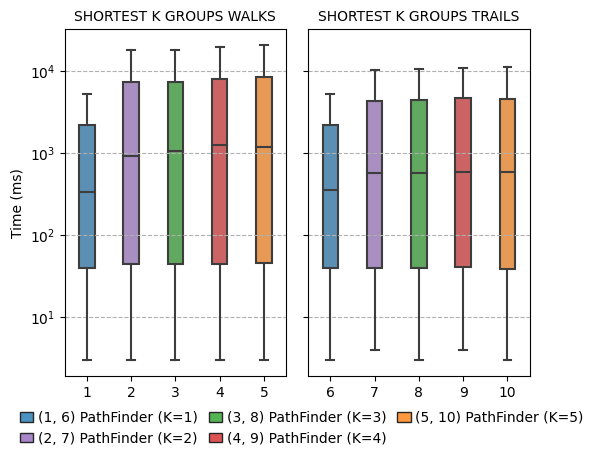

In [7]:
var = 'enum_time_ms'

# Legend
names_a = ['(1, 6) PathFinder (K=1)',
           '(2, 7) PathFinder (K=2)',
           '(3, 8) PathFinder (K=3)',
           '(4, 9) PathFinder (K=4)',
           '(5, 10) PathFinder (K=5)']
legend_colors_a = [0, 4, 2, 3, 1]

# Data for first plot
files_a = ['WDBench/wdbench_shortest_1_groups_walks_bfs.csv',
           'WDBench/wdbench_shortest_2_groups_walks_bfs.csv',
           'WDBench/wdbench_shortest_3_groups_walks_bfs.csv',
           'WDBench/wdbench_shortest_4_groups_walks_bfs.csv',
           'WDBench/wdbench_shortest_5_groups_walks_bfs.csv']
types_a = [0, 1, 2, 3, 4]
colors_a = legend_colors_a
#separators_a = [1.5, 4.5]

# Data for second plot
files_b = ['WDBench/wdbench_shortest_1_groups_trails_bfs.csv',
           'WDBench/wdbench_shortest_2_groups_trails_bfs.csv',
           'WDBench/wdbench_shortest_3_groups_trails_bfs.csv',
           'WDBench/wdbench_shortest_4_groups_trails_bfs.csv',
           'WDBench/wdbench_shortest_5_groups_trails_bfs.csv']
types_b = [5, 6, 7, 8, 9]
colors_b = legend_colors_a
#separators_b = [1.5, 4.5]

# Create box plots
sections = [files_a, files_b]
plot_labels = {'sup_title': 'SHORTEST K GROUPS WALKS + SHORTEST K GROUPS TRAILS',
               'sub_titles': ('SHORTEST K GROUPS WALKS', 'SHORTEST K GROUPS TRAILS'),
               'axes': ('Engine', 'Time (ms)'),
               'legend': [names_a]}
value_settings = {'scale': global_scale,
                  'outliers': global_outliers,
                  'share_y': True,
                  'x_axis': [types_a, types_b],
                  'colors': [colors_a, colors_b],
                  'separators': [None, None]}
general_settings = {'legend_cols': [3],
                    'legend_colors': [legend_colors_a],
                    'figsize': (6, 4.5),
                    'plot_separation': 0.1,
                    'box_width_factor': 0.07,
                    'legend_anchor': [(0.52, 0.06)],
                    'export': True,
                    'output_filename': 'wdbench_shortest_k_groups.pdf'}
generate_box_plots(var, sections, plot_labels, value_settings, general_settings)